# Etna Dataset Construction

This notebook builds the canonical hourly Etna dataset used by the Cause–Trigger analysis. The saved CSV remains in physical or proxy units; transformations and standardization are applied later to the selected reference and case intervals.

In [1]:
import sys
from pathlib import Path
from obspy.clients.fdsn import Client
from obspy.io.mseed import InternalMSEEDWarning
import warnings
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src/etna"
sys.path.append(str(SRC_DIR))

from etna_config import (
    EVENT_TIME,
    ETNA_GAS_METEO_COLS,
    ETNA_WEATHER_COLS,
    ETNA_WAVEFORM_CONFIG,
    etna_observable_metadata,
)
from etna_dataset import (
    create_etna_dataset,
    load_etna_event_catalog_xls,
    load_etnagas_csv,
    load_openmeteo_etna_weather,
)
from etna_plotting_utils import (
    dataset_health_report,
    distribution_summary,
    plot_etna_all_variables_map,
    plot_etna_thesis_figures,
    run_teleseismic_checks,
    plot_etna_loglog_distributions,
)
from etna_waveform import build_station_waveform_dataset

warnings.filterwarnings(
    "ignore",
    category=InternalMSEEDWarning,
    message=r".*fractional second.*10000.*",
)

### Etna seismic-station screening

Candidate vertical seismic streams within 30 km of Etna were screened using short daily waveform probes. Streams were ranked by data availability, distance from the summit, and channel type. Based on this screening, IV.ESLN..HHZ was selected for constructing the teleseismic proxy.

In [2]:
# This is not required for routine dataset reconstruction 
from etna_stations import (
    export_station_screening_results,
    run_station_screening,
)

# True to run station screening, False to skip and use existing results
RUN_STATION_SCREENING = False

if RUN_STATION_SCREENING:
    (
        candidate_streams,
        station_daily_probe,
        station_summary,
    ) = run_station_screening(
        client=Client("INGV"),
        waveform_cfg=ETNA_WAVEFORM_CONFIG,
        max_distance_km=30.0,
        channel_pattern="*HZ",
        probe_offset_hours=12,
        probe_duration_minutes=10,
        min_coverage_fraction=0.80,
        verbose=True,
        display_func=display,
    )

    station_screening_paths = export_station_screening_results(
        station_summary=station_summary,
        daily_probe=station_daily_probe,
        out_dir="../data/etna",
        waveform_cfg=ETNA_WAVEFORM_CONFIG,
        probe_offset_hours=12,
        probe_duration_minutes=10,
    )

    display(station_summary.head(20))

    for name, path in station_screening_paths.items():
        print(f"{name}: {path}")
else:
    print(
        "Station screening skipped. "
        "Set RUN_STATION_SCREENING = True to reproduce the ESLN selection."
    )

Station screening skipped. Set RUN_STATION_SCREENING = True to reproduce the ESLN selection.


## Hourly teleseismic waveform proxy

ESLN HHZ data are processed in padded daily chunks. The proxy is the hourly maximum of non-overlapping 120-second RMS values in the 0.03–0.30 Hz band.

An hourly value requires at least 20 of the 30 expected RMS windows. Four isolated hours that fail this requirement remain missing in the waveform cache and are filled only during final dataset construction using the geometric mean of their adjacent positive hourly values.

In [ ]:
waveform_df, waveform_failures = build_station_waveform_dataset(
    client=Client("INGV"),
    station=ETNA_WAVEFORM_CONFIG["station"],
    config=ETNA_WAVEFORM_CONFIG,
    cache_path="../data/etna/etna_esln_hhz_waveform.pkl",
    redownload=False, # True to re-download of waveform data, False to use cached data
)

print(f"Waveform rows: {len(waveform_df)}")
print(f"Failed daily chunks: {len(waveform_failures)}")
if waveform_failures:
    display(pd.DataFrame(waveform_failures, columns=["date", "error"]))

ESLN OK   2008-03-01 | missing hourly values=1
ESLN OK   2008-03-02
ESLN OK   2008-03-03
ESLN OK   2008-03-04
ESLN OK   2008-03-05
ESLN OK   2008-03-06
ESLN OK   2008-03-07 | missing hourly values=3
ESLN OK   2008-03-08
ESLN OK   2008-03-09
ESLN OK   2008-03-10
ESLN OK   2008-03-11
ESLN OK   2008-03-12
ESLN OK   2008-03-13
ESLN OK   2008-03-14 | missing hourly values=2
ESLN OK   2008-03-15 | missing hourly values=2
ESLN OK   2008-03-16
ESLN OK   2008-03-17 | missing hourly values=1
ESLN OK   2008-03-18 | missing hourly values=2
ESLN OK   2008-03-19 | missing hourly values=2
ESLN OK   2008-03-20 | missing hourly values=2
ESLN OK   2008-03-21
ESLN OK   2008-03-22
ESLN OK   2008-03-23
ESLN OK   2008-03-24
ESLN OK   2008-03-25
ESLN OK   2008-03-26
ESLN OK   2008-03-27
ESLN OK   2008-03-28
ESLN OK   2008-03-29 | missing hourly values=1
ESLN OK   2008-03-30
ESLN OK   2008-03-31 | missing hourly values=2
ESLN OK   2008-04-01 | missing hourly values=6
ESLN OK   2008-04-02 | missing hourly valu

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\obspy\io\mseed\util.py:683: UserWarning: Record contains a fractional seconds (.0001 secs) of 10000 - the maximum strictly allowed value is 9999. It will be interpreted as one or more additional seconds.
  warnings.warn(


ESLN OK   2008-04-22 | missing hourly values=1
ESLN OK   2008-04-23 | missing hourly values=1
ESLN OK   2008-04-24
ESLN OK   2008-04-25
ESLN OK   2008-04-26
ESLN OK   2008-04-27
ESLN OK   2008-04-28
ESLN OK   2008-04-29
ESLN OK   2008-04-30 | missing hourly values=1
ESLN OK   2008-05-01
ESLN OK   2008-05-02
ESLN OK   2008-05-03
ESLN OK   2008-05-04
ESLN OK   2008-05-05
ESLN OK   2008-05-06
ESLN OK   2008-05-07
ESLN OK   2008-05-08
ESLN OK   2008-05-09
ESLN OK   2008-05-10
ESLN OK   2008-05-11
ESLN OK   2008-05-12
ESLN OK   2008-05-13
ESLN OK   2008-05-14
ESLN OK   2008-05-15
ESLN OK   2008-05-16
ESLN OK   2008-05-17
ESLN OK   2008-05-18
ESLN OK   2008-05-19 | missing hourly values=4
ESLN: saved waveform features to ..\data\etna\etna_esln_hhz_waveform.pkl
Waveform rows: 1920
Failed daily chunks: 0


In [4]:
missing_teleseismic = waveform_df.loc[
    waveform_df["teleseismic"].isna()
]

print(f"Missing teleseismic hours: {len(missing_teleseismic)}")
display(missing_teleseismic)

Missing teleseismic hours: 48


,teleseismic
time,
2008-03-01 18:00:00+00:00,NaN
2008-03-07 09:00:00+00:00,NaN
2008-03-07 10:00:00+00:00,NaN
2008-03-07 11:00:00+00:00,NaN
2008-03-14 08:00:00+00:00,NaN
2008-03-14 11:00:00+00:00,NaN
2008-03-15 06:00:00+00:00,NaN
2008-03-15 09:00:00+00:00,NaN
2008-03-17 11:00:00+00:00,NaN


## External variables

The retained external variables are soil CO₂ concentration and atmospheric pressure drop from ETNAGAS, plus hourly Open-Meteo precipitation. Isolated one-hour ETNAGAS gaps are linearly interpolated and reported explicitly.

Liuzzo, M., Giuffrida, G. B., & Gurrieri, S. (2025). *Etna CO2 Soil Flux during 2002–2010 (ECSF2002_2010)*. INGV. https://doi.org/10.13127/etna/ecsf2002_2010

Zippenfenig, P. (2023). *Open-Meteo.com Weather API*. Zenodo. https://doi.org/10.5281/ZENODO.7970649

In [5]:
etnagas_df, etnagas_interpolation_report = load_etnagas_csv(
    "../data/etna/3c.csv",
    value_cols=ETNA_GAS_METEO_COLS,
    start_time=ETNA_WAVEFORM_CONFIG["start"].isoformat(),
    end_time=ETNA_WAVEFORM_CONFIG["end"].isoformat(),
)

display(etnagas_interpolation_report)

,timestamp,interpolated_variables,method,maximum_gap
0,2008-05-06 13:00:00+00:00,"CO2_3, Patm_3",linear time interpolation,1 hour
1,2008-05-11 22:00:00+00:00,"CO2_3, Patm_3",linear time interpolation,1 hour
2,2008-05-13 13:00:00+00:00,"CO2_3, Patm_3",linear time interpolation,1 hour


In [ ]:
weather_cache = Path("../data/etna/etna_openmeteo_hourly.csv")

if weather_cache.exists():
    weather_df = pd.read_csv(
        weather_cache,
        parse_dates=["timestamp"],
    )
    weather_df["timestamp"] = pd.to_datetime(
        weather_df["timestamp"],
        utc=True,
    )
else:
    weather_df = load_openmeteo_etna_weather(
        start_date=ETNA_WAVEFORM_CONFIG["start"].strftime("%Y-%m-%d"),
        end_date=ETNA_WAVEFORM_CONFIG["end"].strftime("%Y-%m-%d"),
    )
    weather_df.to_csv(weather_cache, index=False)

print(f"Weather rows: {len(weather_df)}")

Weather rows: 1944


## Mt. Etna Seismic Catalogue 2000–2010

The catalogue supplies two hourly variables:

- `local_event_rate_state`: a past-only 48-hour local-seismicity state ending six hours before the current hour;
- `local_event_rate_response`: a positive six-hour event-count response relative to an earlier past baseline, used as the effect variable.

Alparone, S. C., Maiolino, V., Mostaccio, A., Scaltrito, A., Ursino, A., Barberi, G., et al. (2015). *Mt. Etna Seismic Catalog 2000–2010* [Data set]. INGV–Osservatorio Etneo. https://doi.org/10.13127/etnasc/2000_2010

In [7]:
catalogue = load_etna_event_catalog_xls(
    "../data/etna/Etna catalogue_2000-2010.xls",
    quality_filter=False,
)

print(f"Catalogue rows: {len(catalogue)}")
print(
    "Catalogue range:",
    catalogue["timestamp"].min(),
    "to",
    catalogue["timestamp"].max(),
)

Catalogue rows: 6328
Catalogue range: 2000-01-01 01:21:26+00:00 to 2010-12-31 05:53:46+00:00


## Save the hourly dataset

All sources are joined by exact UTC hourly timestamps. The leading rows lacking the required past-only catalogue windows are removed. Four isolated teleseismic gaps are filled using geometric interpolation between adjacent positive hourly values; no multi-hour waveform gaps or other final variables are imputed.

In [8]:
etna_dataset = create_etna_dataset(
    wave_df=waveform_df,
    start_time=ETNA_WAVEFORM_CONFIG["start"].isoformat(),
    end_time=ETNA_WAVEFORM_CONFIG["end"].isoformat(),
    catalog_df=catalogue,
    etnagas_df=etnagas_df,
    etnagas_cols=ETNA_GAS_METEO_COLS,
    weather_df=weather_df,
    weather_cols=ETNA_WEATHER_COLS,
    output_dir="../data/etna",
)

ValueError: Final Etna dataset contains missing values:
rainfall_mm    1075
teleseismic      27
dtype: int64

## Construction audit

This compact audit reports the final hourly-grid integrity, waveform failures, the leading rows removed for past-only proxy warm-up, and ETNAGAS interpolation count.

In [ ]:
expected_hours = int(
    (ETNA_WAVEFORM_CONFIG["end"] - ETNA_WAVEFORM_CONFIG["start"]) / 3600
)

audit = dataset_health_report(
    etna_dataset,
    "Etna canonical hourly dataset",
)
audit["waveform_failed_chunks"] = len(waveform_failures)
audit["proxy_warmup_rows_removed"] = expected_hours - len(etna_dataset)
audit["etnagas_interpolated_hours"] = len(
    etnagas_interpolation_report
)
audit["teleseismic_interpolated_hours"] = len(
    missing_teleseismic
)
display(audit)
display(distribution_summary(etna_dataset))

,dataset,rows,variables,start,end,duplicate_timestamps,time_sorted,regular_hourly_grid,missing_cells,waveform_failed_chunks,proxy_warmup_rows_removed,etnagas_interpolated_hours,teleseismic_interpolated_hours
0,Etna canonical hourly dataset,787,6,2008-04-13 05:00:00+00:00,2008-05-15 23:00:00+00:00,0,True,True,0,0,29,3,4


,count,mean,std,min,median,max,skew,n_unique,missing_fraction
CO2_3,787.0,1.475448e-01,0.021588,9.718300e-02,1.433440e-01,0.212085,0.223187,164,0.0
local_event_rate_response,787.0,2.465008e-01,0.493311,0.000000e+00,0.000000e+00,3.258097,2.648462,31,0.0
local_event_rate_state,787.0,1.609146e+00,0.805061,0.000000e+00,1.609438e+00,3.737670,0.683825,36,0.0
pressure_drop,787.0,-2.435630e-03,0.407693,-1.201602e+00,4.291400e-02,1.015640,-0.248652,296,0.0
rainfall_mm,787.0,7.407878e-02,0.291550,0.000000e+00,0.000000e+00,5.400000,9.738744,16,0.0
teleseismic,787.0,4.919513e-07,0.000003,7.551051e-08,1.499743e-07,0.000070,17.683103,787,0.0


### Distribution diagnostics


In [ ]:
summary_esln = distribution_summary(etna_dataset)
display(summary_esln)

,count,mean,std,min,median,max,skew,n_unique,missing_fraction
CO2_3,787.0,1.475448e-01,0.021588,9.718300e-02,1.433440e-01,0.212085,0.223187,164,0.0
local_event_rate_response,787.0,2.465008e-01,0.493311,0.000000e+00,0.000000e+00,3.258097,2.648462,31,0.0
local_event_rate_state,787.0,1.609146e+00,0.805061,0.000000e+00,1.609438e+00,3.737670,0.683825,36,0.0
pressure_drop,787.0,-2.435630e-03,0.407693,-1.201602e+00,4.291400e-02,1.015640,-0.248652,296,0.0
rainfall_mm,787.0,7.407878e-02,0.291550,0.000000e+00,0.000000e+00,5.400000,9.738744,16,0.0
teleseismic,787.0,4.919513e-07,0.000003,7.551051e-08,1.499743e-07,0.000070,17.683103,787,0.0


### Log-log distribution diagnostics

These diagnostics use the canonical unscaled variables. True logarithmic axes require positive values, so zeros and negative observations are excluded variable by variable and reported explicitly.

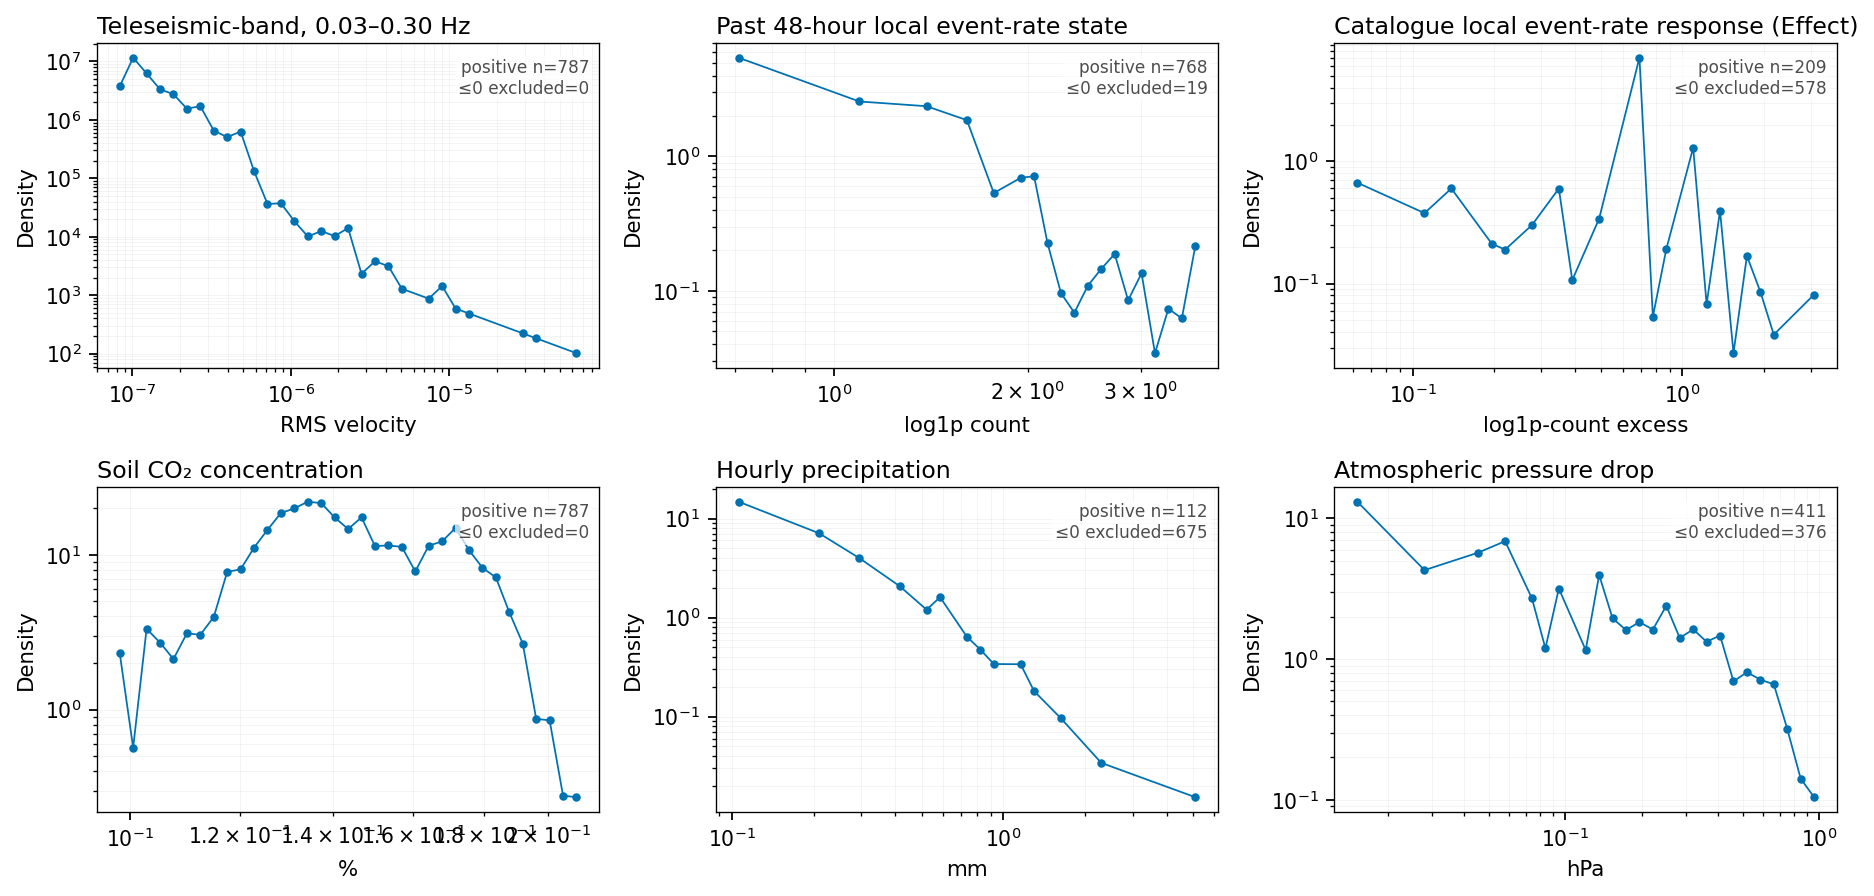

,variable,n_total_nonmissing,n_positive_used,n_nonpositive_excluded,positive_fraction,min_positive,max_positive,n_unique_positive
0,teleseismic,787,787,0,1.000000,7.551051e-08,0.000070,787
1,local_event_rate_state,787,768,19,0.975858,6.931472e-01,3.737670,35
2,local_event_rate_response,787,209,578,0.265565,5.889152e-02,3.258097,30
3,CO2_3,787,787,0,1.000000,9.718300e-02,0.212085,164
4,rainfall_mm,787,112,675,0.142313,1.000000e-01,5.400000,15
5,pressure_drop,787,411,376,0.522236,1.430400e-02,1.015640,147


In [ ]:
fig, axes, etna_loglog_report = plot_etna_loglog_distributions(
    dataframe=etna_dataset,
    save_dir="../figures",
)

display(etna_loglog_report)

### Final overview figures

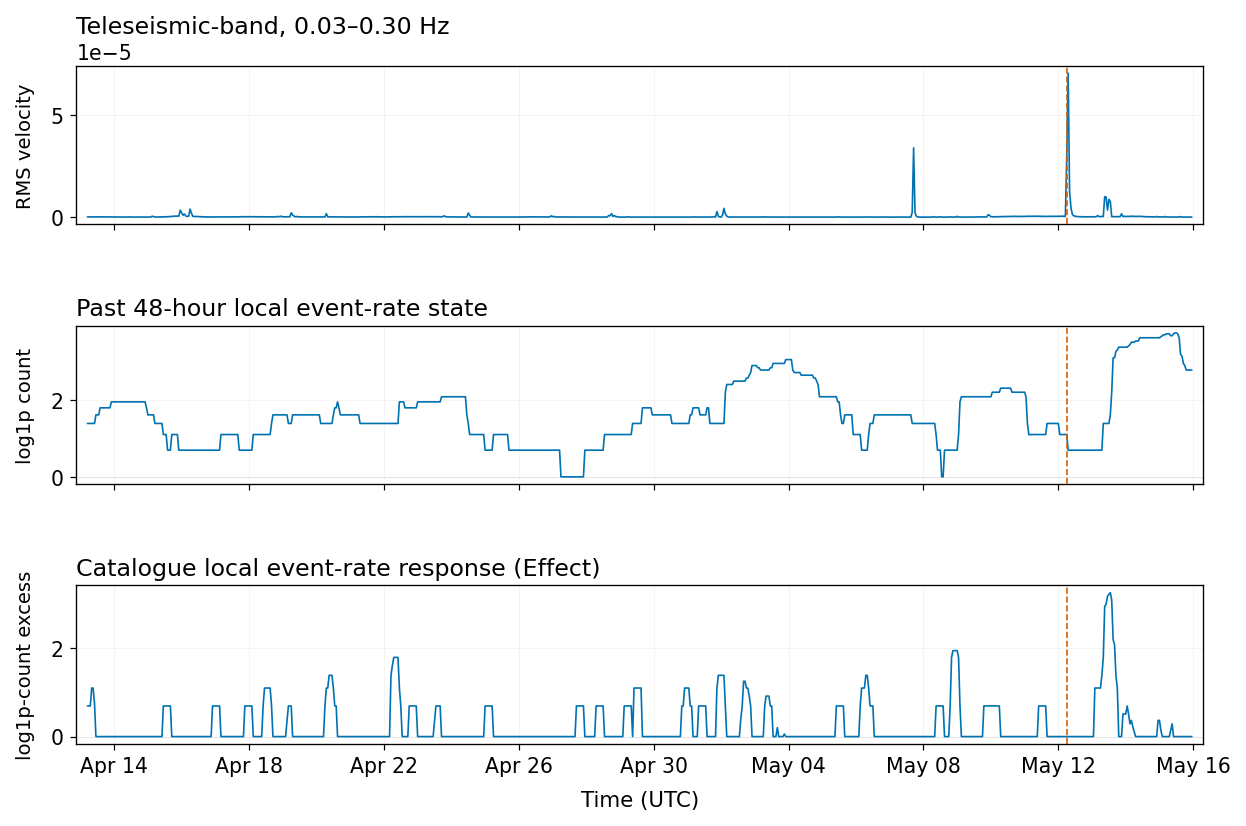

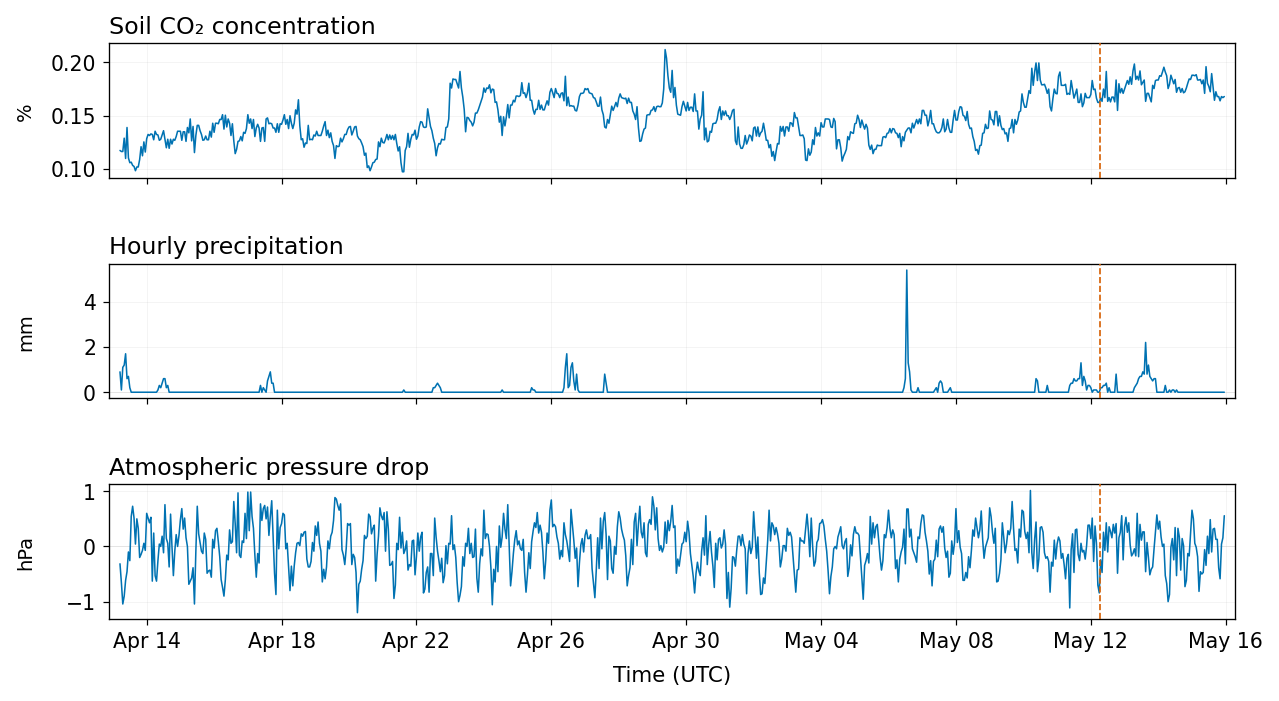

((<Figure size 1280x761.6 with 3 Axes>,
  array([<Axes: title={'left': 'Teleseismic-band, 0.03–0.30 Hz'}, ylabel='RMS velocity'>,
         <Axes: title={'left': 'Past 48-hour local event-rate state'}, ylabel='log1p count'>,
         <Axes: title={'left': 'Catalogue local event-rate response (Effect)'}, xlabel='Time (UTC)', ylabel='log1p-count excess'>],
        dtype=object)),
 (<Figure size 1280x646.4 with 3 Axes>,
  array([<Axes: title={'left': 'Soil CO₂ concentration'}, ylabel='%'>,
         <Axes: title={'left': 'Hourly precipitation'}, ylabel='mm'>,
         <Axes: title={'left': 'Atmospheric pressure drop'}, xlabel='Time (UTC)', ylabel='hPa'>],
        dtype=object)))

In [ ]:
plot_etna_thesis_figures(
    csv_path="../data/etna/etna_dataset.csv",
    event_time=EVENT_TIME,
    save_dir="../figures",
    include_titles=False,
)

### Exact teleseismic-feature diagnostic

The following figures reuse the same response correction, frequency band, 120-second RMS windows, and hourly-maximum aggregation used in the canonical dataset.

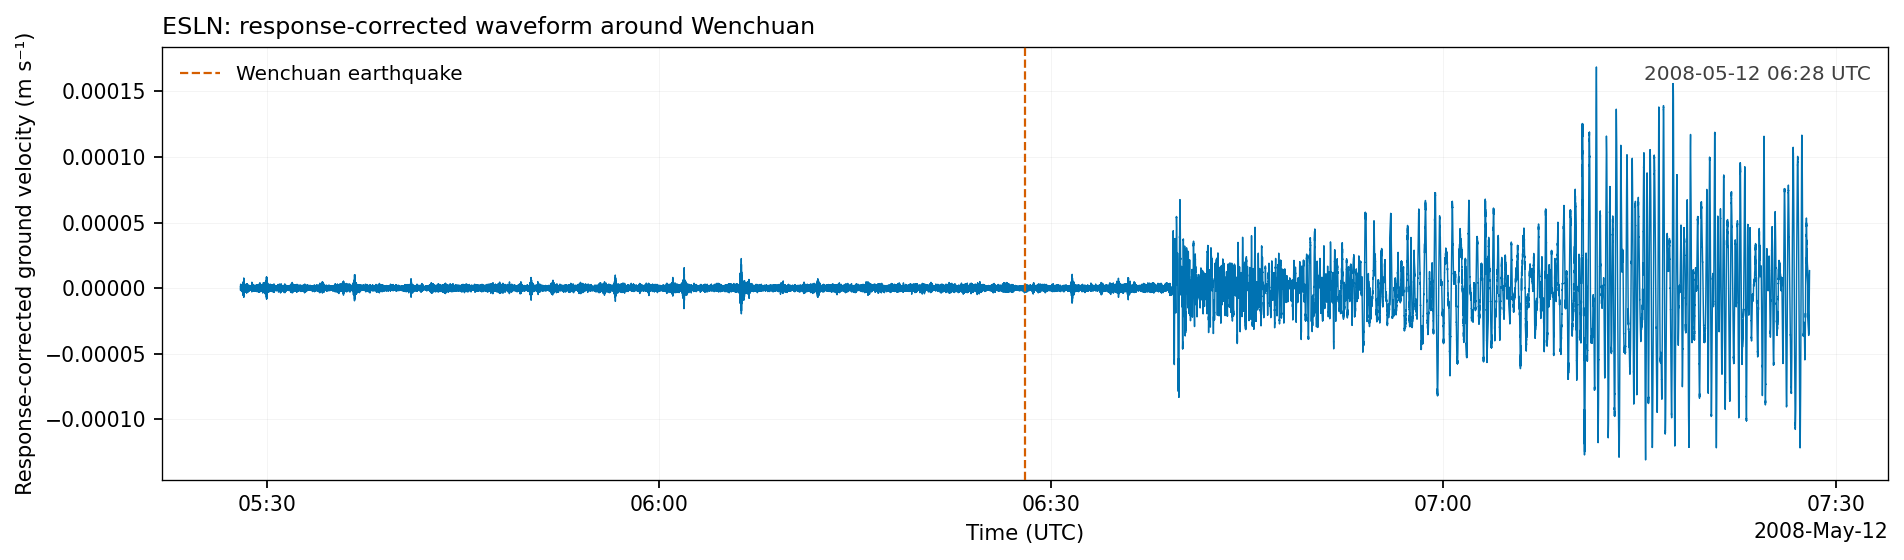

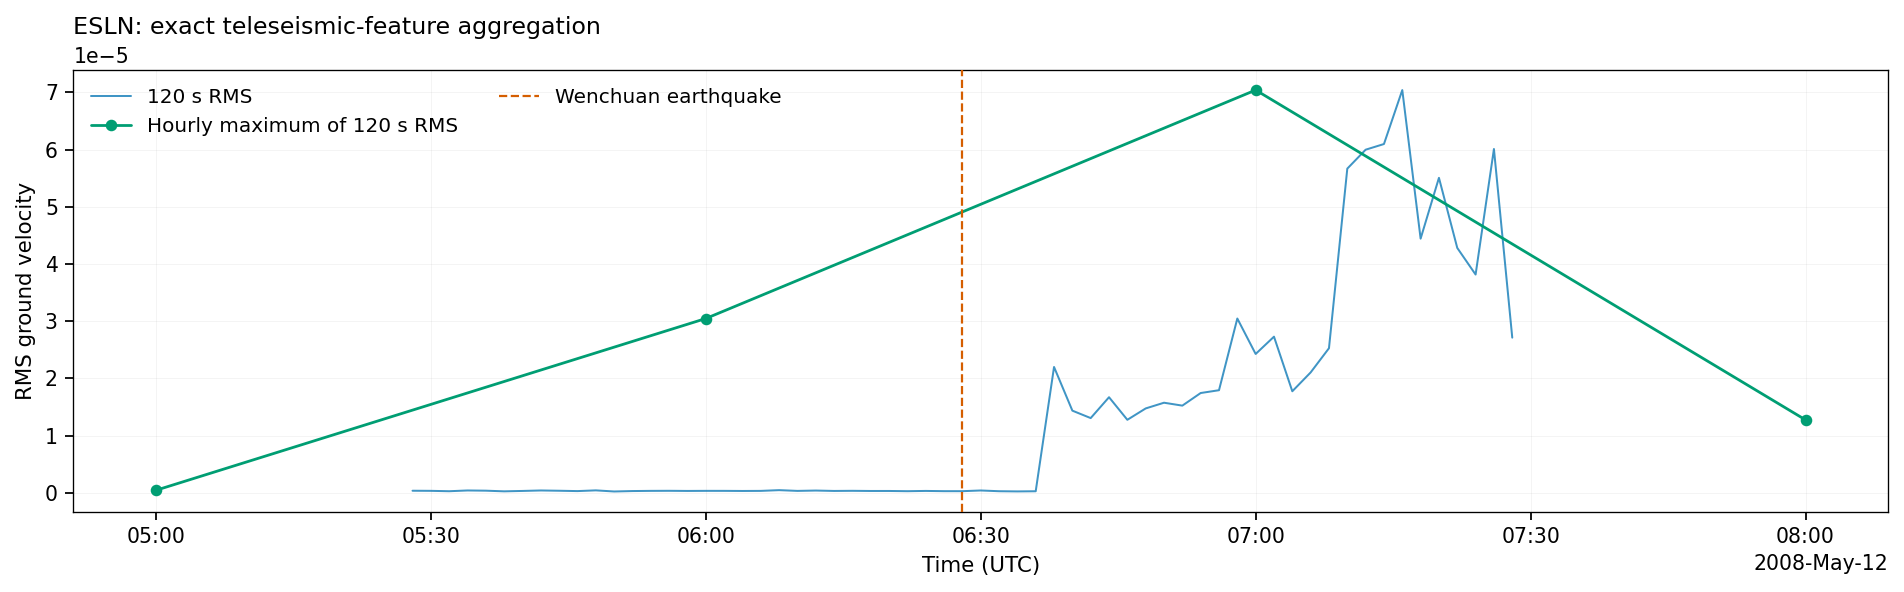

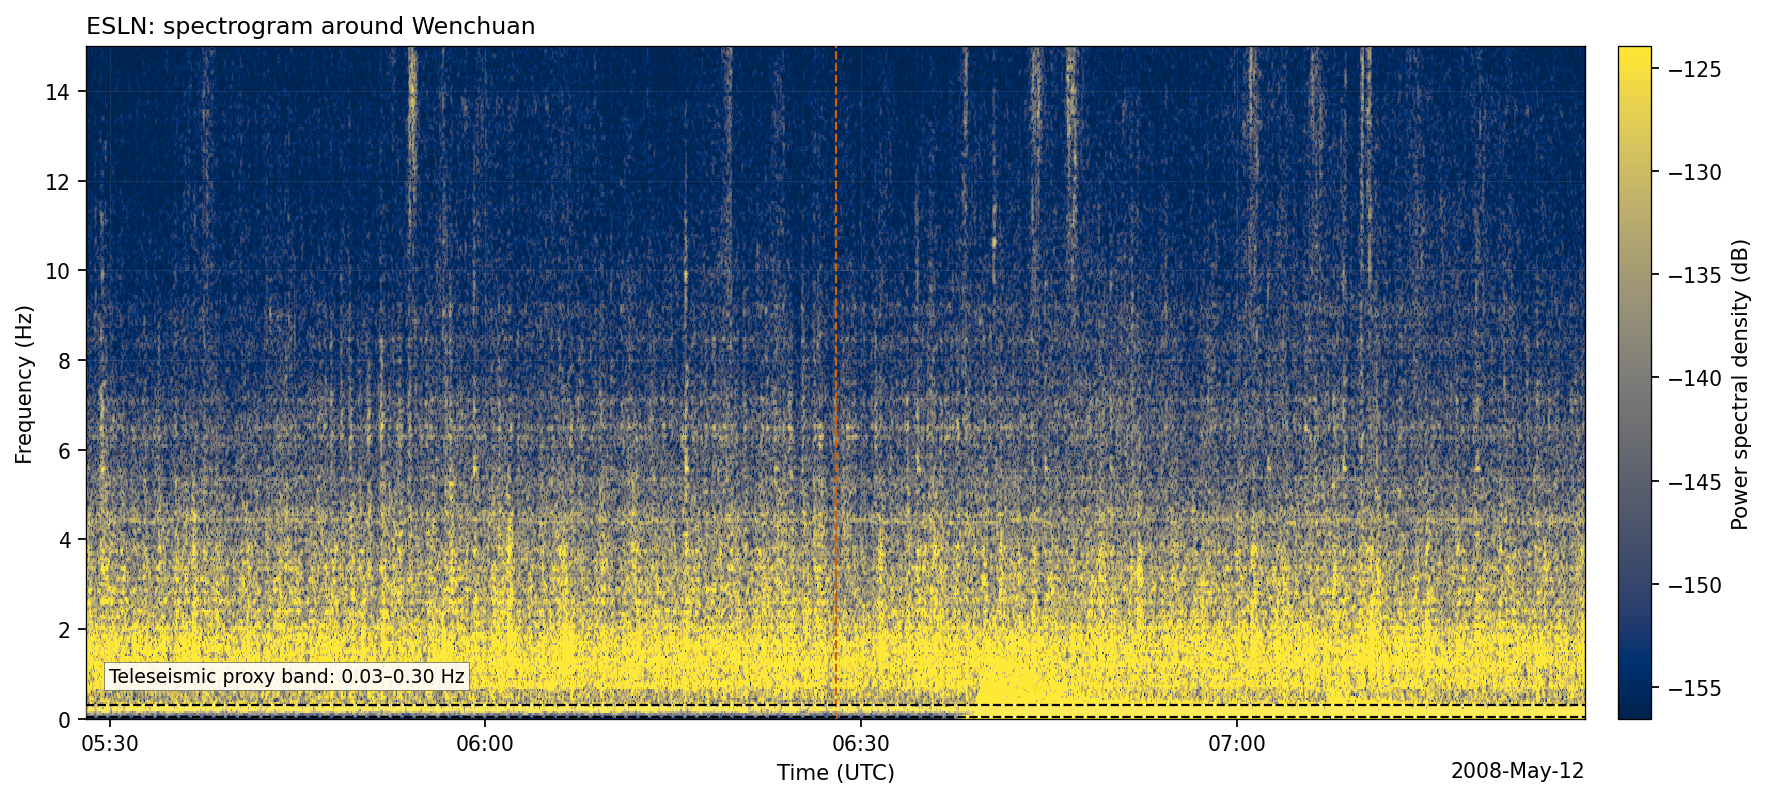

In [ ]:
waveform_client = Client(
    base_url="https://webservices.ingv.it",
    service_mappings={
        "dataselect": "https://webservices.ingv.it/fdsnws/dataselect/1/",
        "station": "https://webservices.ingv.it/fdsnws/station/1/",
        "event": "https://webservices.ingv.it/fdsnws/event/1/",
    },
    _discover_services=False,
)

teleseismic_check = run_teleseismic_checks(
    client=waveform_client,
    station=ETNA_WAVEFORM_CONFIG["station"],
    config=ETNA_WAVEFORM_CONFIG,
    event_time=EVENT_TIME,
    save_dir="../figures",
)

### Geographic Visualization

,Source,Source ID,Variables,Internal names
0,ESLN,ESLN,"Teleseismic-band RMS velocity, 0.03–0.30 Hz",teleseismic
1,ETNAGAS network,ETNAGAS_3,Soil CO₂ concentration; Atmospheric pressure drop,"CO2_3, pressure_drop"
2,EtnaSC catalogue,EtnaSC_2000_2010,Past 48-hour local event-rate state; Positive ...,"local_event_rate_state, local_event_rate_response"
3,Open-Meteo,ETNA_OPENMETEO_PROXY,Hourly precipitation,rainfall_mm


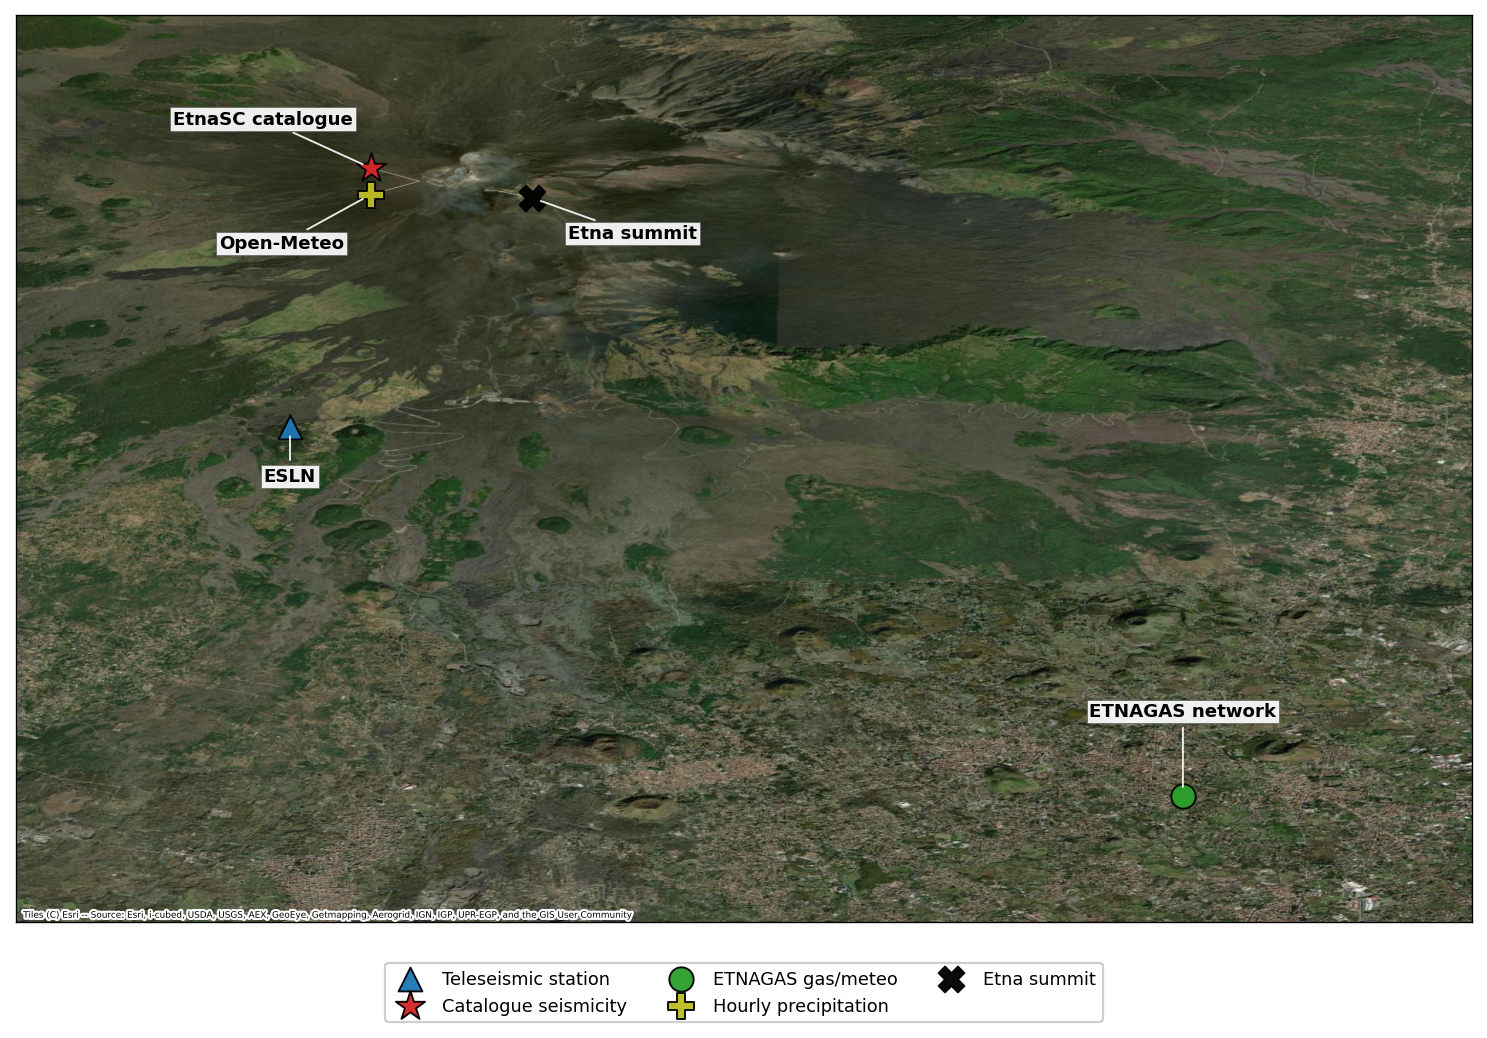

In [ ]:
figure, axis, source_table = plot_etna_all_variables_map(
    metadata=etna_observable_metadata(),
    satellite=True,
    save_dir="../figures",
    filename="etna_map",
)

display(source_table)